In [1]:
import pandas as pd
import numpy as np
from functions import *
X_train_orig = pd.read_csv('../data/X_train.csv', index_col='id')
X_train_filtered = filter_signal(X_train_orig)
X_test_orig = pd.read_csv('../data/X_test.csv', index_col='id')
X_test_filtered = filter_signal(X_test_orig)
y_train_orig = pd.read_csv('../data/y_train.csv', index_col='id')

In [2]:
print("Median number of entries in each times series: ", np.median(np.sum(X_train_filtered.notna(), axis=1)))
print("Minimum number of entries in each times series: ", np.min(np.sum(X_train_filtered.notna(), axis=1)))
print("Size of training data: ", len(X_train_orig))
print(y_train_orig.value_counts())

Median number of entries in each times series:  8370.0
Minimum number of entries in each times series:  2490
Size of training data:  5117
y
0    3030
2    1474
1     443
3     170
dtype: int64


In [3]:
#Padding the sequence with the values in last row to max length
to_pad = 8400 # cut the sequence and impute the missing entries until all have this length
steps = 5 # to reduce time series length on every timepoint is taken
split = 4000 # to create test set with known label
n_1 = 500 # for upsampling
n_2 = 2000 
n_3 = 200

# choose the data to actually train on (after padding)
X_train = X_train_filtered
X_test = X_test_filtered
y_train = y_train_orig

In [4]:
# shuffle data
idx = np.random.permutation(len(X_train))
X_train = X_train.iloc[idx]
y_train = y_train.iloc[idx]

X_train_padded = pd.DataFrame(np.ones((len(X_train),to_pad)))
for i in range(len(X_train)):
    one_seq = X_train.iloc[i,0:to_pad].dropna()
    len_one_seq = len(one_seq)
    last_val = one_seq[-1]
    n = to_pad - len_one_seq
   
    to_concat = np.repeat(one_seq[-1], n)
    new_one_seq = np.concatenate([one_seq, to_concat])
    X_train_padded.iloc[i,:] = new_one_seq
X_train_padded = X_train_padded.iloc[:,::steps]

X_test_padded = pd.DataFrame(np.ones((len(X_test),to_pad)))
for i in range(len(X_test)):
    one_seq = X_test.iloc[i,0:to_pad].dropna()
    len_one_seq = len(one_seq)
    last_val = one_seq[-1]
    n = to_pad - len_one_seq
   
    to_concat = np.repeat(one_seq[-1], n)
    new_one_seq = np.concatenate([one_seq, to_concat])
    X_test_padded.iloc[i,:] = new_one_seq
X_test_padded = X_test_padded.iloc[:,::steps]

# creat test set with labels
test = X_train_padded.iloc[split:,:]
test_target = y_train.iloc[split:,:]
train = X_train_padded.iloc[:split,:]
train_target = y_train.iloc[:split]

# validation sample actually not needed for second model
# from sklearn.model_selection import train_test_split
# train, validation, train_target, validation_target = train_test_split(X_train_padded, y_train, test_size=0.33, random_state=42)

# balance classes
# from sklearn.utils import resample
# df_1=train[np.array(train_target["y"]==1)]
# df_2=train[np.array(train_target["y"]==2)]
# df_3=train[np.array(train_target["y"]==3)]
# df_0=train[np.array(train_target["y"]==0)]

# df_1_upsample=resample(df_1,replace=True,n_samples=n_1,random_state=123)
# df_2_upsample=resample(df_2,replace=True,n_samples=n_2,random_state=124)
# df_3_upsample=resample(df_3,replace=True,n_samples=n_3,random_state=125)

# train=pd.concat([df_0,df_1_upsample,df_2_upsample,df_3_upsample],axis=0)
# train_target=pd.DataFrame([0]*len(df_0)+[1]*n_1+[2]*n_2+[3]*n_3)

# shuffle data
idx = np.random.permutation(len(train))
train = train.iloc[idx]
train_target = train_target.iloc[idx]

# get data in right dimension
train = np.array(train).reshape((train.shape[0], train.shape[1], 1))
# validation = np.array(validation).reshape((validation.shape[0], validation.shape[1], 1))
test = np.array(test).reshape((test.shape[0], test.shape[1], 1))

In [5]:
print(train_target.value_counts())
print(test_target.value_counts())

y
0    2382
2    1129
1     353
3     136
dtype: int64
y
0    648
2    345
1     90
3     34
dtype: int64


In [6]:
# cnn lstm model
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers import Dropout
from keras.layers import LSTM
from keras.layers import TimeDistributed
from keras.layers import Normalization
from keras.layers.convolutional import Conv1D
from keras.layers.convolutional import MaxPooling1D
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.optimizers import Adam
from keras.models import load_model
from keras.callbacks import ModelCheckpoint

In [7]:
classes = len(np.unique(train_target))

model = Sequential()
model.add(LSTM(50, input_shape=(train_target.shape[1], 1)))
model.add(Dropout(0.5))
model.add(Dense(100, activation='relu'))
model.add(Dense(classes, activation='softmax'))
model.summary()

Metal device set to: Apple M1 Pro

systemMemory: 16.00 GB
maxCacheSize: 5.33 GB

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm (LSTM)                  (None, 50)                10400     
_________________________________________________________________
dropout (Dropout)            (None, 50)                0         
_________________________________________________________________
dense (Dense)                (None, 100)               5100      
_________________________________________________________________
dense_1 (Dense)              (None, 4)                 404       
Total params: 15,904
Trainable params: 15,904
Non-trainable params: 0
_________________________________________________________________


2021-11-27 17:24:54.256996: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2021-11-27 17:24:54.257495: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [8]:
# adam = Adam(learning_rate=0.001)
# chk = ModelCheckpoint('best_model.pkl', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
# model.compile(loss='sparse_categorical_crossentropy', optimizer=adam, metrics=['accuracy'])
# model.fit(train, train_target, epochs=10, batch_size=200, callbacks=[chk], validation_data=(validation,validation_target))


In [9]:
#loading the model and checking accuracy on the test data
model = load_model('best_model.pkl')

from sklearn.metrics import f1_score
predict_x=model.predict(test) 
classes_x=np.argmax(predict_x,axis=1)
f1_score(test_target, classes_x, average='micro')

2021-11-27 17:24:55.286866: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)
2021-11-27 17:24:55.289363: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2021-11-27 17:24:55.388285: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.
2021-11-27 17:24:55.411268: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


0.5801253357206804

In [10]:
from tensorflow import keras
def make_CNN(input_shape):
    input_layer = keras.layers.Input(input_shape)
    normalisation_layer = Normalization()(input_layer)

    # conv0 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(normalisation_layer) # , kernel_regularizer='l2'
    # conv0 = keras.layers.BatchNormalization()(conv0)
    # conv0 = keras.layers.ReLU()(conv0)

    conv1 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(normalisation_layer) 
    conv1 = keras.layers.BatchNormalization()(conv1)
    conv1 = keras.layers.ReLU()(conv1)

    conv2 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv1)
    conv2 = keras.layers.BatchNormalization()(conv2)
    conv2 = keras.layers.ReLU()(conv2)
    
    conv3 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv2)
    conv3 = keras.layers.BatchNormalization()(conv3)
    conv3 = keras.layers.ReLU()(conv3)

    # conv4 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv3)
    # conv4 = keras.layers.BatchNormalization()(conv4)
    # conv4 = keras.layers.ReLU()(conv4)

    # conv5 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv4)
    # conv5 = keras.layers.BatchNormalization()(conv5)
    # conv5 = keras.layers.ReLU()(conv5)

    # conv6 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv5)
    # conv6 = keras.layers.BatchNormalization()(conv6)
    # conv6 = keras.layers.ReLU()(conv6)

    # conv7 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv6)
    # conv7 = keras.layers.BatchNormalization()(conv7)
    # conv7 = keras.layers.ReLU()(conv7)

    # dropout = keras.layers.Dropout(0.5)(conv3)
    # dropout = keras.layers.Dense(25)(dropout)

    gap = keras.layers.GlobalAveragePooling1D()(conv3)

    output_layer = keras.layers.Dense(4, activation="softmax")(gap)

    return keras.models.Model(inputs=input_layer, outputs=output_layer)

In [11]:
def make_LSTM(input_shape):
    input_layer = keras.layers.Input(input_shape)
    normalisation_layer = Normalization()(input_layer)

    conv1 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(normalisation_layer) 
    conv1 = keras.layers.BatchNormalization()(conv1)
    conv1 = keras.layers.ReLU()(conv1)

    gap = keras.layers.MaxPooling1D()(conv1)

    LSTM1 = keras.layers.LSTM(50)(gap)

    dense0 = keras.layers.Dense(20, activation='relu')(LSTM1)

    dense0 = keras.layers.Dropout(0.5)(dense0)

    dense1 = keras.layers.Dense(20, activation='relu')(dense0)

    output_layer = keras.layers.Dense(4, activation="softmax")(dense1)

    return keras.models.Model(inputs=input_layer, outputs=output_layer)


In [12]:
model= make_LSTM(input_shape=train.shape[1:]) # make_CNN(input_shape=train.shape[1:])
# keras.utils.plot_model(model, show_shapes=True)
model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 1680, 1)]         0         
_________________________________________________________________
normalization (Normalization (None, 1680, 1)           3         
_________________________________________________________________
conv1d (Conv1D)              (None, 1680, 64)          384       
_________________________________________________________________
batch_normalization (BatchNo (None, 1680, 64)          256       
_________________________________________________________________
re_lu (ReLU)                 (None, 1680, 64)          0         
_________________________________________________________________
max_pooling1d (MaxPooling1D) (None, 840, 64)           0         
_________________________________________________________________
lstm_1 (LSTM)                (None, 50)                23000 

In [13]:
epochs = 500
batch_size = 200

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_model.h5", save_best_only=True, monitor="val_loss"
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=20, min_lr=0.00001
    ),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=50, verbose=1),
]
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"],
)
history = model.fit(
    train,
    train_target,
    batch_size=batch_size,
    epochs=epochs,
    callbacks=callbacks,
    validation_split=0.2,
    verbose=1,
)

Epoch 1/500


2021-11-27 17:25:18.554294: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.
2021-11-27 17:25:18.863045: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.
2021-11-27 17:25:21.434139: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


16/16 [==============================] - ETA: 0s - loss: 1.3642 - sparse_categorical_accuracy: 0.4894

2021-11-27 17:25:31.993852: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.
2021-11-27 17:25:32.038763: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


16/16 [==============================] - 17s 561ms/step - loss: 1.3642 - sparse_categorical_accuracy: 0.4894 - val_loss: 1.2585 - val_sparse_categorical_accuracy: 0.5863
Epoch 2/500
16/16 [==============================] - 6s 396ms/step - loss: 1.2507 - sparse_categorical_accuracy: 0.5784 - val_loss: 1.1100 - val_sparse_categorical_accuracy: 0.5875
Epoch 3/500
16/16 [==============================] - 6s 399ms/step - loss: 1.1041 - sparse_categorical_accuracy: 0.5813 - val_loss: 1.0488 - val_sparse_categorical_accuracy: 0.5875
Epoch 4/500
16/16 [==============================] - 6s 398ms/step - loss: 1.0570 - sparse_categorical_accuracy: 0.5906 - val_loss: 1.0397 - val_sparse_categorical_accuracy: 0.5875
Epoch 5/500
16/16 [==============================] - 6s 396ms/step - loss: 1.0471 - sparse_categorical_accuracy: 0.5959 - val_loss: 1.0433 - val_sparse_categorical_accuracy: 0.5875
Epoch 6/500
16/16 [==============================] - 6s 396ms/step - loss: 1.0457 - sparse_categorical_acc

In [14]:
model = keras.models.load_model("best_model.h5")

test_loss, test_acc = model.evaluate(test,test_target)

print("Test accuracy", test_acc)
print("Test loss", test_loss)

2021-11-27 17:43:32.451528: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.
2021-11-27 17:43:32.512006: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


35/35 [==============================] - 8s 152ms/step - loss: 0.9780 - sparse_categorical_accuracy: 0.5864
Test accuracy 0.5863921642303467
Test loss 0.977958619594574


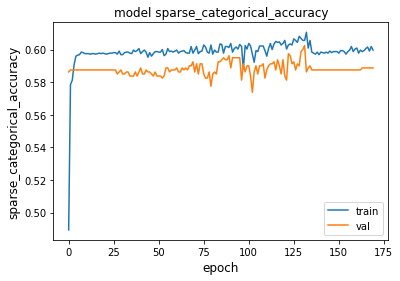

In [15]:
metric = "sparse_categorical_accuracy"
plt.figure()
plt.plot(history.history[metric])
plt.plot(history.history["val_" + metric])
plt.title("model " + metric)
plt.ylabel(metric, fontsize="large")
plt.xlabel("epoch", fontsize="large")
plt.legend(["train", "val"], loc="best")
plt.show()
plt.close()

In [16]:
from sklearn.metrics import f1_score
predict_x=model.predict(test) 
classes_x=np.argmax(predict_x,axis=1)
f1_score(test_target, classes_x, average='micro')

2021-11-27 17:43:40.230736: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.
2021-11-27 17:43:40.265981: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


0.5863921217547001

In [17]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(test_target, classes_x))
print("Confusion Matrix:\n", confusion_matrix(test_target, classes_x))

              precision    recall  f1-score   support

           0       0.59      0.98      0.74       648
           1       0.00      0.00      0.00        90
           2       0.43      0.06      0.10       345
           3       0.00      0.00      0.00        34

    accuracy                           0.59      1117
   macro avg       0.26      0.26      0.21      1117
weighted avg       0.48      0.59      0.46      1117

Confusion Matrix:
 [[635   0  13   0]
 [ 80   0  10   0]
 [325   0  20   0]
 [ 31   0   3   0]]


/Users/juliusc/miniforge3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1308: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/juliusc/miniforge3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1308: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/juliusc/miniforge3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1308: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# Predict

In [18]:
# predict final test set
y_test = pd.DataFrame({'id' : range(X_test_padded.shape[0])})
predict_x=model.predict(X_test_padded) 
y_test['y'] = np.argmax(predict_x,axis=1)
y_test.to_csv('../out/y_test.csv', index=False)

2021-11-27 17:43:47.731758: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.
2021-11-27 17:43:47.765281: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


In [19]:
print(y_test['y'].value_counts())

0    3265
2     146
Name: y, dtype: int64
